Architecture & Pipeline Configuration:
This cell establishes the global configuration for the entire model pipeline. It sets data processing limits derived from our 99th-percentile Exploratory Data Analysis, caps the vocabulary to prevent Softmax probability dilution, and defines the structural dimensions of the neural network. It also establishes the special tokens required for sequence boundaries and padding, and automatically detects whether a GPU is available for hardware acceleration.

In [1]:
# ==========================================
# CELL 1: ARCHITECTURE & PIPELINE CONFIGURATION
# ==========================================
import torch

class Config:
    # --- Data Processing Parameters ---
    MAX_INPUT_LENGTH = 60    # 99th percentile of inputs
    MAX_TARGET_LENGTH = 55   # 99th percentile of targets
    MAX_VOCAB_SIZE = 15000   # Covers 97.35% of vocabulary
    SAMPLE_SIZE = 100000     # Manageable subset for local/rapid training
    
    # --- Model Dimensions ---
    EMBEDDING_DIM = 256      # Dense vector space
    HIDDEN_DIM = 512         # High capacity memory
    BATCH_SIZE = 64          # Stable batch size
    
    # --- Training Parameters ---
    EPOCHS = 10
    LEARNING_RATE = 0.0001   # Smoother convergence
    TEACHER_FORCING_RATIO = 0.5 
    PATIENCE = 2             # Early stopping threshold
    
    # --- Special Tokens ---
    PAD_token = 0           
    UNK_token = 1           
    SOS_token = 2           
    EOS_token = 3           
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Smart Tokenization & Preprocessing: This step handles the extraction, cleaning, and preparation of the raw conversational data. It pairs consecutive messages into input-target sets and applies a highly specialized regular expression tokenizer. Unlike standard tokenizers that split blindly by spaces, this regex is explicitly designed to preserve technical Linux vocabulary, such as file paths (/etc/apt), terminal commands (--help), and package versions, while safely scrubbing URLs, email addresses, and isolated punctuation. Helper function merge_ubuntu_csvs() creating a master_dialogue.csv file. 

In [ ]:
import pandas as pd
import glob
import os

def merge_ubuntu_csvs(output_filename="master_dialogue.csv"):
    # Find all dialogue CSVs in your directory
    all_files = glob.glob("dialogueText*.csv")
    print(f"Found {len(all_files)} files to merge: {all_files}")
    
    # We will append to a new CSV piece by piece to save RAM
    first_file = True
    
    for file in all_files:
        print(f"Processing {file}...")
        # Read in chunks of 100,000 rows
        chunk_container = pd.read_csv(file, chunksize=100000, on_bad_lines='skip')
        
        for chunk in chunk_container:
            # Drop empty text rows immediately to save space
            chunk = chunk.dropna(subset=['text'])
            
            # Append to master file
            chunk.to_csv(output_filename, mode='w' if first_file else 'a', 
                         header=first_file, index=False)
            first_file = False
            
    print(f"Merging complete! Master dataset saved as '{output_filename}'")

# Run the merger
merge_ubuntu_csvs()

In [2]:
# ==========================================
# CELL 2: SMART TOKENIZATION & PREPROCESSING
# ==========================================
import pandas as pd
import re
from collections import Counter
from sklearn.model_selection import train_test_split

print("Loading raw dataset...")
# --- UPDATE THIS FILENAME TO YOUR ACTUAL RAW CSV ---
df_raw = pd.read_csv("master_dialogue.csv")

# 1. Pairing Logic from Reference Notebook
print("Pairing consecutive messages...")
df_raw = df_raw.dropna(subset=["text"]).copy()
df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")
df_raw = df_raw.dropna(subset=["date"]).copy()

# Sort chronologically within each dialogue thread
df_raw = df_raw.sort_values(by=["folder", "dialogueID", "date"]).copy()

# Shift text by -1 to create the target response for each input
df_raw["target_text"] = df_raw.groupby(["folder", "dialogueID"])["text"].shift(-1)
df_raw["input_text"] = df_raw["text"]

# Drop terminal messages that have no response
df = df_raw.dropna(subset=["input_text", "target_text"]).copy()

print(f"Sampling {Config.SAMPLE_SIZE} pairs...")
df_model = df.sample(n=Config.SAMPLE_SIZE, random_state=42).copy()

# 2. Regex Definitions
regex_url = r'https?://\S+|www\.\S+'
regex_email = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'

# Advanced tokenizer that preserves Linux paths and commands
token_pattern = re.compile(r"""
    <url>|<email>|                      # URL and email placeholders
    /[a-zA-Z0-9._/\-]+|                 # file paths, e.g. /etc/apt/sources.list
    --?[a-zA-Z0-9][a-zA-Z0-9._\-]*|     # commands/options, e.g. apt-get, --help
    [a-zA-Z0-9]+(?:[._\-][a-zA-Z0-9]+)* # words, package names, versions
""", re.VERBOSE)

def clean_and_tokenize(text):
    text = str(text)
    text = re.sub(regex_url, ' <url> ', text)    
    text = re.sub(regex_email, ' <email> ', text)
    text = text.lower()                          
    return token_pattern.findall(text)           

print("Tokenizing... (This may take a minute)")
df_model["input_tokens"] = df_model["input_text"].apply(clean_and_tokenize)
df_model["target_tokens"] = df_model["target_text"].apply(clean_and_tokenize)

# Filter out empty token lists and overly long sequences
df_model = df_model[
    (df_model["input_tokens"].str.len() > 0) & 
    (df_model["input_tokens"].str.len() <= Config.MAX_INPUT_LENGTH) &
    (df_model["target_tokens"].str.len() > 0) &
    (df_model["target_tokens"].str.len() <= Config.MAX_TARGET_LENGTH)
].copy()

print(f"Data cleaned and paired! Remaining pairs: {len(df_model)}")

Loading raw dataset...
Pairing consecutive messages...
Sampling 100000 pairs...
Tokenizing... (This may take a minute)
Data cleaned and paired! Remaining pairs: 97859


Top-K Vocabulary Generation:
To optimize mathematical stability and prevent the model from defaulting to generic responses, this cell analyzes the frequency of all tokens across the sampled dataset. It strictly caps the vocabulary at the top 15,000 most frequent tokens, achieving over 97% language coverage while discarding the massive long-tail of unique typos and niche IDs. It then translates all text tokens into machine-readable integer sequences.

In [3]:
# ==========================================
# CELL 3: TOP-K VOCABULARY GENERATION
# ==========================================
print("Building Top-K Vocabulary...")

# Count all tokens
token_counts = Counter()
for tokens in df_model["input_tokens"]: token_counts.update(tokens)
for tokens in df_model["target_tokens"]: token_counts.update(tokens)

# Keep only the top 15,000 most frequent tokens
most_common = token_counts.most_common(Config.MAX_VOCAB_SIZE)

vocab = {"<pad>": 0, "<unk>": 1, "<sos>": 2, "<eos>": 3}
for word, _ in most_common:
    if word not in vocab:
        vocab[word] = len(vocab)

index2word = {idx: word for word, idx in vocab.items()}

def tokens_to_seq(tokens, is_target=False):
    seq = [vocab.get(token, Config.UNK_token) for token in tokens]
    if is_target:
        seq = [Config.SOS_token] + seq + [Config.EOS_token]
    return seq

# Apply integer mapping
df_model["input_seq"] = df_model["input_tokens"].apply(lambda x: tokens_to_seq(x, False))
df_model["target_seq"] = df_model["target_tokens"].apply(lambda x: tokens_to_seq(x, True))
df_model["input_length"] = df_model["input_seq"].apply(len)

print(f"Vocabulary mapped! Total words: {len(vocab)}")

Building Top-K Vocabulary...
Vocabulary mapped! Total words: 15004


Datasets & DataLoaders: The integer sequences are packaged into a robust PyTorch Dataset and partitioned into an 80/10/10 split for Training, Validation, and Testing. To enable batch processing without corrupting the model's learning, shorter sequences are padded to match the maximum length thresholds. Crucially, the dataset explicitly calculates and tracks the true unpadded length of every input sequence so the neural network knows exactly where the meaningful data ends and the padding begins.

In [5]:
# ==========================================
# CELL 4: DATASETS & DATALOADERS
# ==========================================
from torch.utils.data import Dataset, DataLoader

class BotDataset(Dataset):
    def __init__(self, dataframe):
        self.inputs = dataframe["input_seq"].tolist()
        self.targets = dataframe["target_seq"].tolist()
        self.input_lengths = dataframe["input_length"].tolist()

    def __len__(self): return len(self.inputs)

    def __getitem__(self, idx):
        # Pad input
        inp = self.inputs[idx]
        inp_padded = inp + [Config.PAD_token] * (Config.MAX_INPUT_LENGTH - len(inp))
        
        # Pad target
        tgt = self.targets[idx]
        tgt_padded = tgt + [Config.PAD_token] * ((Config.MAX_TARGET_LENGTH + 2) - len(tgt))
        
        return (
            torch.tensor(inp_padded, dtype=torch.long),
            torch.tensor(tgt_padded, dtype=torch.long),
            torch.tensor(self.input_lengths[idx], dtype=torch.long)
        )

# 80/10/10 Split
df_train, df_temp = train_test_split(df_model, test_size=0.20, random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42)

train_loader = DataLoader(BotDataset(df_train), batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(BotDataset(df_val), batch_size=Config.BATCH_SIZE, shuffle=False)

print(f"DataLoaders generated! Training batches: {len(train_loader)}")

DataLoaders generated! Training batches: 1224


Attention Architecture with Sequence Packing:
This cell defines the core mathematical architecture of the Seq2Seq model. It features three primary components:

PackedEncoder: A GRU that dynamically ignores <pad> tokens using PyTorch's pack_padded_sequence utility, preventing the model from learning "ghost" padding patterns.

BahdanauAttention: An alignment mechanism that calculates attention weights, allowing the model to focus on specific, relevant words from the input prompt during each step of generation.

AttentionDecoder: A GRU that integrates the attention context vector with its own hidden state to predict the most logical next word in the sequence.

In [8]:
# ==========================================
# CELL 5: ATTENTION ARCHITECTURE WITH SEQUENCE PACKING
# ==========================================
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class PackedEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=Config.PAD_token)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

    def forward(self, input_seq, input_lengths):
        embedded = self.embedding(input_seq)
        # Pack the sequence to dynamically ignore padding
        packed = pack_padded_sequence(embedded, input_lengths.cpu(), batch_first=True, enforce_sorted=False)
        
        packed_outputs, hidden = self.gru(packed)
        
        # Unpack back to normal tensors for the Attention mechanism
        outputs, _ = pad_packed_sequence(packed_outputs, batch_first=True, total_length=Config.MAX_INPUT_LENGTH)
        return outputs, hidden

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, hidden, encoder_outputs):
        hidden_expanded = hidden.unsqueeze(1)
        score = self.V(torch.tanh(self.W1(encoder_outputs) + self.W2(hidden_expanded)))
        attention_weights = F.softmax(score, dim=1)
        context_vector = torch.sum(attention_weights * encoder_outputs, dim=1)
        return context_vector, attention_weights

class AttentionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=Config.PAD_token)
        self.attention = BahdanauAttention(hidden_dim)
        self.gru = nn.GRU(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden, encoder_outputs):
        embedded = self.embedding(x)
        context_vector, attention_weights = self.attention(hidden[-1], encoder_outputs)
        gru_input = torch.cat([embedded, context_vector.unsqueeze(1)], dim=-1)
        output, hidden = self.gru(gru_input, hidden)
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden, attention_weights

Training Engine & Early Stopping (NaN-Proof)
This is the main optimization loop that trains the neural network. It feeds the loaded batches into the model, calculates the Cross-Entropy loss (strictly ignoring <pad> computations to prevent zero-division NaN crashes), and updates the network weights using the Adam optimizer. It features gradient clipping for stability and an Early Stopping mechanism that halts training if the validation loss plateaus, preventing the model from overfitting to the training data.

In [18]:
# ==========================================
# CELL 6: TRAINING ENGINE & EARLY STOPPING (CLEAN LOGGING)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import random

def train_validate_epoch(encoder, decoder, dataloader, criterion, optimizer=None, is_train=True):
    if is_train:
        encoder.train()
        decoder.train()
        mode = "Train"
    else:
        encoder.eval()
        decoder.eval()
        mode = "Val"
        
    total_loss = 0
    total_batches = len(dataloader)
    
    with torch.set_grad_enabled(is_train):
        for batch_idx, (src, trg, src_lens) in enumerate(dataloader):
            src, trg = src.to(Config.device), trg.to(Config.device)
            
            if is_train:
                optimizer.zero_grad()
                
            batch_size = src.size(0)
            trg_len = trg.size(1)
            
            # Pass inputs and exact lengths to the PackedEncoder
            encoder_outputs, hidden = encoder(src, src_lens)
            dec_input = trg[:, 0].unsqueeze(1) # Start with <SOS> token
            loss = 0
            timestep_count = 0 # Track active steps to avoid NaN division
            
            use_teacher_forcing = True if is_train and random.random() < Config.TEACHER_FORCING_RATIO else False
            
            for t in range(1, trg_len):
                # Guard against 100% padding slices
                if (trg[:, t] != Config.PAD_token).any():
                    prediction, hidden, _ = decoder(dec_input, hidden, encoder_outputs)
                    loss += criterion(prediction, trg[:, t])
                    timestep_count += 1
                    
                    if use_teacher_forcing:
                        dec_input = trg[:, t].unsqueeze(1)
                    else:
                        dec_input = prediction.argmax(1).unsqueeze(1)
                else:
                    # All sequences in this batch have finished; skip the empty padding!
                    break
                    
            if timestep_count > 0:
                if is_train:
                    loss.backward()
                    # Gradient clipping to ensure stable weights
                    torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
                    torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)
                    optimizer.step()
                    
                batch_loss = loss.item() / timestep_count
                total_loss += batch_loss
            
            # Clean Logging: Print an update every 200 batches
            if (batch_idx + 1) % 200 == 0 or (batch_idx + 1) == total_batches:
                current_avg_loss = total_loss / (batch_idx + 1)
                print(f"   -> {mode} Batch {batch_idx + 1:04d}/{total_batches} | Avg Loss: {current_avg_loss:.4f}")
                
    return total_loss / total_batches

# --- EXECUTION SCRIPT ---
print(f"Initializing Modular Attention Pipeline on {Config.device}...")
encoder = PackedEncoder(len(vocab), Config.EMBEDDING_DIM, Config.HIDDEN_DIM).to(Config.device)
decoder = AttentionDecoder(len(vocab), Config.EMBEDDING_DIM, Config.HIDDEN_DIM).to(Config.device)

# Link both model parameters to the optimizer
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=Config.LEARNING_RATE)
# Ensure padding is ignored in loss calculations
criterion = nn.CrossEntropyLoss(ignore_index=vocab["<pad>"])

best_val_loss = float('inf')
patience_counter = 0

print(f"Starting Training for {Config.EPOCHS} Epochs...")
for epoch in range(1, Config.EPOCHS + 1):
    print(f"\n--- Epoch {epoch:02d}/{Config.EPOCHS} ---")
    
    train_loss = train_validate_epoch(encoder, decoder, train_loader, criterion, optimizer, is_train=True)
    val_loss = train_validate_epoch(encoder, decoder, val_loader, criterion, is_train=False)
    
    print(f"Epoch {epoch:02d} Summary | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(encoder.state_dict(), 'attn_encoder_v2.pth')
        torch.save(decoder.state_dict(), 'attn_decoder_v2.pth')
        print("Validation loss improved. Checkpoint Saved!")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{Config.PATIENCE}")
        if patience_counter >= Config.PATIENCE:
            print("\n[!] Early Stopping Triggered. Model has converged.")
            break

print("\nTraining Sequence Complete. Ready for Evaluation!")

Initializing Modular Attention Pipeline on cuda...
Starting Training for 10 Epochs...

--- Epoch 01/10 ---
   -> Train Batch 0200/1224 | Avg Loss: 7.1609
   -> Train Batch 0400/1224 | Avg Loss: 6.6530
   -> Train Batch 0600/1224 | Avg Loss: 6.4742
   -> Train Batch 0800/1224 | Avg Loss: 6.3697
   -> Train Batch 1000/1224 | Avg Loss: 6.3082
   -> Train Batch 1200/1224 | Avg Loss: 6.2619
   -> Train Batch 1224/1224 | Avg Loss: 6.2567
   -> Val Batch 0153/153 | Avg Loss: 6.0984
Epoch 01 Summary | Train Loss: 6.2567 | Val Loss: 6.0984
Validation loss improved. Checkpoint Saved!

--- Epoch 02/10 ---
   -> Train Batch 0200/1224 | Avg Loss: 5.9814
   -> Train Batch 0400/1224 | Avg Loss: 5.9614
   -> Train Batch 0600/1224 | Avg Loss: 5.9385
   -> Train Batch 0800/1224 | Avg Loss: 5.9188
   -> Train Batch 1000/1224 | Avg Loss: 5.9025
   -> Train Batch 1200/1224 | Avg Loss: 5.8954
   -> Train Batch 1224/1224 | Avg Loss: 5.8954
   -> Val Batch 0153/153 | Avg Loss: 6.1296
Epoch 02 Summary | Train 

In-Depth Evaluation Pipeline: This comprehensive evaluation suite tests the model's generative intelligence. It utilizes an Advanced Constrained Beam Search algorithm equipped with minimum length requirements, repetition penalties, and length normalization to force the model to construct rich, descriptive sentences. The pipeline calculates BLEU-4 and ROUGE-L accuracy metrics, generates comparative scatter plots and score distributions, and visualizes the exact alignment of the neural network's focus using a Bahdanau Attention Heatmap.

Running Beam Search Evaluation on 100 samples...

GENERATIVE EVALUATION SUMMARY


,Metric,Score
0,Average BLEU-4,0.0243
1,Average ROUGE-L,0.1149
2,Avg Target Length,9.4700
3,Avg Generated Length,9.9000


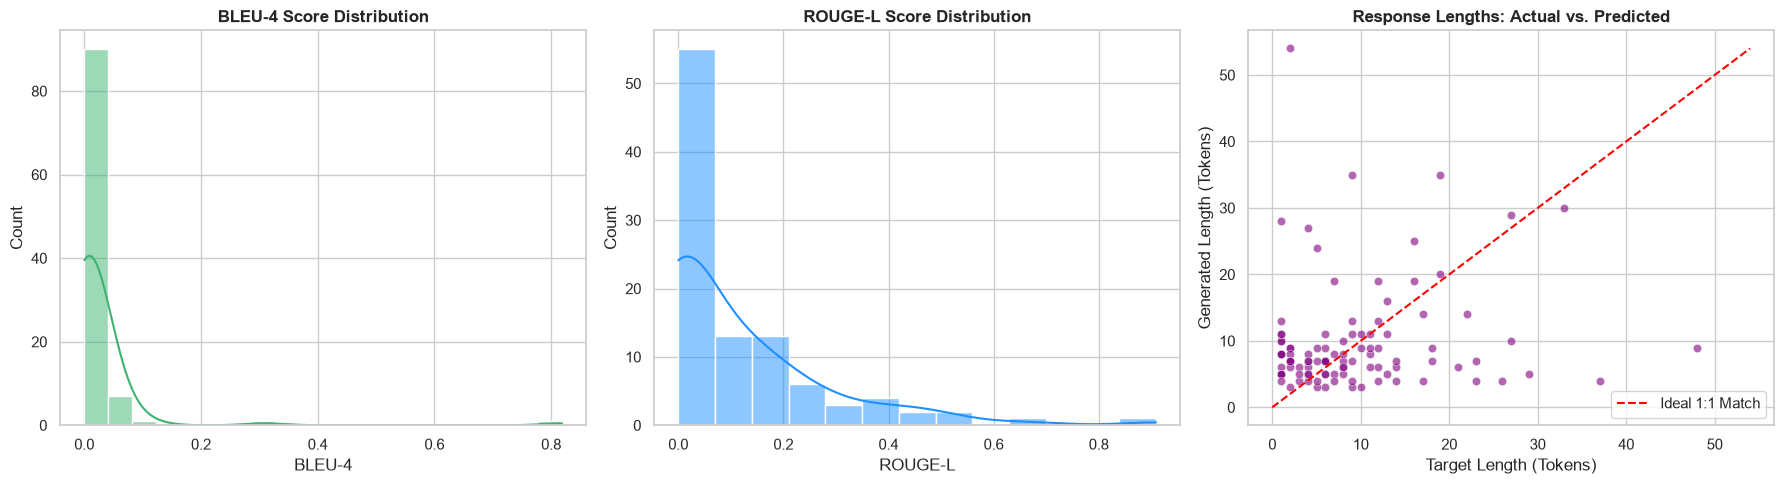


 Deep-Dive Attention Analysis for: 'how to list files in directory'
Model Predicted: how do i need to install in ubuntu


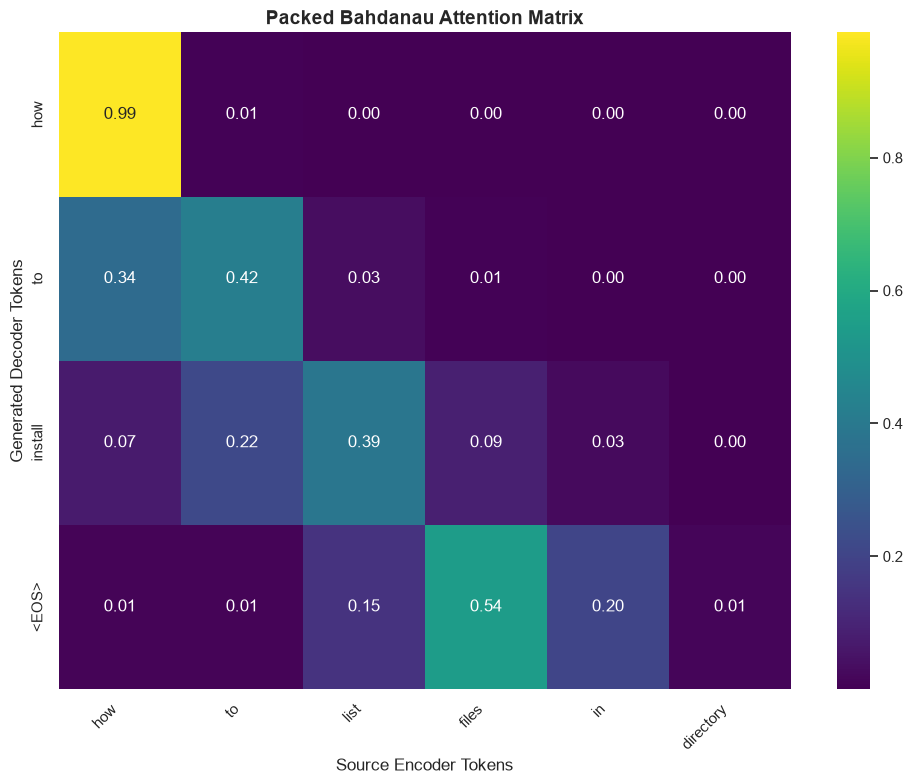


 Sample Generated Responses:


,Input,Prediction,Target
0,this is what i'm trying to do. sudo imagemagi...,this is what you want to do sudo apt-get insta...,"also, you might want to find a better tutorial..."
1,Program for editing movies and uploading to yo...,thanks for me and i m trying to get it to work...,"Hmmn, I just need it to put a video on Youtube..."
2,which firewall?,i you have to do that,you'll need to forward port 22 to your interna...
3,im afraid to install ubuntu and lose windows c...,i m trying to install ubuntu,yeah i was busy
4,there is xdesktop meta pakacge for sfce I guess,there is a <unk>,do you mean xubuntu-desktop?


In [19]:
# ==========================================
# CELL 7: IN-DEPTH EVALUATION PIPELINE
# ==========================================
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# --- 1. ADVANCED CONSTRAINED BEAM SEARCH ---
def beam_search_decode(encoder, decoder, input_text, vocab, index2word, device, beam_width=5, alpha=1.2, min_length=4):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        # Tokenize using the advanced Regex tokenizer
        tokens = clean_and_tokenize(input_text)
        if not tokens: 
            tokens = ["<unk>"]
            
        # Convert to integer sequence
        seq = [vocab.get(t, vocab["<unk>"]) for t in tokens]
        seq_len = min(len(seq), Config.MAX_INPUT_LENGTH)
        
        # Pad sequence to match expected tensor dimensions
        padded_seq = seq + [vocab["<pad>"]] * (Config.MAX_INPUT_LENGTH - len(seq))
        padded_seq = padded_seq[:Config.MAX_INPUT_LENGTH]
        
        # Create Tensors
        src_tensor = torch.tensor([padded_seq], dtype=torch.long, device=device)
        len_tensor = torch.tensor([seq_len], dtype=torch.long, device=device)
        
        # Encode
        encoder_outputs, hidden = encoder(src_tensor, len_tensor)
        
        beams = [(0.0, [vocab["<sos>"]], hidden)]
        
        for step in range(Config.MAX_TARGET_LENGTH):
            new_beams = []
            for score, current_seq, dec_hidden in beams:
                # If this beam already hit <eos>, carry it forward
                if current_seq[-1] == vocab["<eos>"]:
                    new_beams.append((score, current_seq, dec_hidden))
                    continue
                    
                dec_input = torch.tensor([[current_seq[-1]]], dtype=torch.long, device=device)
                prediction, next_hidden, _ = decoder(dec_input, dec_hidden, encoder_outputs)
                
                log_probs = F.log_softmax(prediction, dim=1).squeeze(0)
                
                # --- CONSTRAINT 1: Minimum Length ---
                # Forbid <eos> if the sentence is too short
                if len(current_seq) < min_length:
                    log_probs[vocab["<eos>"]] = float('-inf')
                
                # --- CONSTRAINT 2: Repetition Penalty ---
                # Forbid the model from predicting the exact same word it just predicted
                if len(current_seq) > 1:
                    last_word_idx = current_seq[-1]
                    log_probs[last_word_idx] = float('-inf')
                
                topk_probs, topk_idx = log_probs.topk(beam_width)
                
                for i in range(beam_width):
                    new_seq = current_seq + [topk_idx[i].item()]
                    new_score = score + topk_probs[i].item()
                    new_beams.append((new_score, new_seq, next_hidden))
            
            # --- CONSTRAINT 3: Length Normalization ---
            # Alpha > 1.0 heavily favors longer sentences
            new_beams = sorted(new_beams, key=lambda x: x[0] / (len(x[1])**alpha), reverse=True)
            beams = new_beams[:beam_width]
            
            if all(b[1][-1] == vocab["<eos>"] for b in beams):
                break
                
    best_seq = beams[0][1]
    decoded_words = [index2word.get(idx, "<unk>") for idx in best_seq if idx not in [vocab["<pad>"], vocab["<sos>"], vocab["<eos>"]]]
    return " ".join(decoded_words)

# --- 2. ATTENTION HEATMAP VISUALIZER ---
def plot_attention_heatmap(encoder, decoder, input_text, vocab, index2word, device):
    encoder.eval()
    decoder.eval()
    
    tokens = clean_and_tokenize(input_text)
    if not tokens: tokens = ["<unk>"]
    
    with torch.no_grad():
        seq = [vocab.get(t, vocab["<unk>"]) for t in tokens]
        seq_len = min(len(seq), Config.MAX_INPUT_LENGTH)
        padded_seq = seq + [vocab["<pad>"]] * (Config.MAX_INPUT_LENGTH - len(seq))
        padded_seq = padded_seq[:Config.MAX_INPUT_LENGTH]
        
        src_tensor = torch.tensor([padded_seq], dtype=torch.long, device=device)
        len_tensor = torch.tensor([seq_len], dtype=torch.long, device=device)
        
        encoder_outputs, hidden = encoder(src_tensor, len_tensor)
        dec_input = torch.tensor([[vocab["<sos>"]]], device=device)
        
        decoded_words = []
        decoder_attentions = []
        
        for _ in range(Config.MAX_TARGET_LENGTH):
            prediction, hidden, attention_weights = decoder(dec_input, hidden, encoder_outputs)
            
            # Save only the attention weights corresponding to the actual input length
            decoder_attentions.append(attention_weights.squeeze().cpu().numpy()[:seq_len])
            
            top1 = prediction.argmax(1).item()
            if top1 == vocab["<eos>"]:
                decoded_words.append('<EOS>')
                break
            else:
                decoded_words.append(index2word.get(top1, '<unk>'))
            dec_input = torch.tensor([[top1]], device=device)
            
    attention_matrix = np.array(decoder_attentions)
    input_tokens_display = tokens[:seq_len]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(attention_matrix, xticklabels=input_tokens_display, yticklabels=decoded_words, 
                cmap='viridis', annot=True, fmt=".2f")
    plt.title("Packed Bahdanau Attention Matrix", fontsize=14, fontweight="bold")
    plt.xlabel("Source Encoder Tokens", fontsize=12)
    plt.ylabel("Generated Decoder Tokens", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# --- 3. MASTER VISUAL EVALUATOR ---
class VisualEvaluator:
    def __init__(self, vocab, index2word, device):
        self.vocab = vocab
        self.index2word = index2word
        self.device = device
        self.rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
        self.smooth = SmoothingFunction().method1
        sns.set_theme(style="whitegrid")

    def run_pipeline(self, encoder, decoder, df_test, sample_size=100):
        print(f"Running Beam Search Evaluation on {sample_size} samples...")
        
        metrics = []
        test_sample = df_test.sample(n=sample_size, random_state=42)
        
        for idx, row in test_sample.iterrows():
            src_text = row["input_text"]
            trg_text = row["target_text"]
            
            pred_text = beam_search_decode(encoder, decoder, src_text, self.vocab, self.index2word, self.device)
            if not pred_text.strip(): pred_text = "<empty>"
            
            ref_tokens, pred_tokens = clean_and_tokenize(trg_text), pred_text.split()
            
            bleu = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=self.smooth)
            rouge = self.rouge.score(" ".join(ref_tokens), pred_text)['rougeL'].fmeasure
            
            metrics.append({
                "Input": src_text,
                "Target": trg_text,
                "Prediction": pred_text,
                "BLEU-4": bleu,
                "ROUGE-L": rouge,
                "Ref_Len": len(ref_tokens),
                "Pred_Len": len(pred_tokens)
            })

        results_df = pd.DataFrame(metrics)
        
        # Print Summary Table
        print("\n" + "="*50)
        print("GENERATIVE EVALUATION SUMMARY")
        print("="*50)
        summary_stats = pd.DataFrame({
            "Metric": ["Average BLEU-4", "Average ROUGE-L", "Avg Target Length", "Avg Generated Length"],
            "Score": [results_df["BLEU-4"].mean(), results_df["ROUGE-L"].mean(), results_df["Ref_Len"].mean(), results_df["Pred_Len"].mean()]
        })
        display(summary_stats.style.format({"Score": "{:.4f}"}))
        print("="*50 + "\n")

        self._plot_metrics(results_df)
        return results_df

    def _plot_metrics(self, df):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # BLEU Distribution
        sns.histplot(df["BLEU-4"], kde=True, color="mediumseagreen", ax=axes[0])
        axes[0].set_title("BLEU-4 Score Distribution", fontweight="bold")
        
        # ROUGE Distribution
        sns.histplot(df["ROUGE-L"], kde=True, color="dodgerblue", ax=axes[1])
        axes[1].set_title("ROUGE-L Score Distribution", fontweight="bold")
        
        # Length Scatter
        sns.scatterplot(data=df, x="Ref_Len", y="Pred_Len", alpha=0.6, color="purple", ax=axes[2])
        max_val = max(df["Ref_Len"].max(), df["Pred_Len"].max())
        axes[2].plot([0, max_val], [0, max_val], color='red', linestyle='--', label="Ideal 1:1 Match")
        axes[2].set_title("Response Lengths: Actual vs. Predicted", fontweight="bold")
        axes[2].set_xlabel("Target Length (Tokens)")
        axes[2].set_ylabel("Generated Length (Tokens)")
        axes[2].legend()
        
        plt.tight_layout()
        plt.show()

# --- 4. EXECUTION ---
# Load weights if running independently (assuming you ran the training cell previously)
# encoder.load_state_dict(torch.load('attn_encoder_v2.pth'))
# decoder.load_state_dict(torch.load('attn_decoder_v2.pth'))

# Run the complete dashboard
evaluator = VisualEvaluator(vocab, index2word, Config.device)
results_dataframe = evaluator.run_pipeline(encoder, decoder, df_test, sample_size=100)


# Generate an Attention Heatmap for a sample query
test_query = "how to list files in directory"
print(f"\n Deep-Dive Attention Analysis for: '{test_query}'")

print(f"Model Predicted: {beam_search_decode(encoder, decoder, test_query, vocab, index2word, Config.device)}")

plot_attention_heatmap(encoder, decoder, test_query, vocab, index2word, Config.device)

# Display Top 5 Generated Responses
print("\n Sample Generated Responses:")
display(results_dataframe[["Input", "Prediction", "Target"]].head(5))

Export Models:
Once training and evaluation are complete, this cell packages the model for real-world deployment. It exports the frozen neural network weights (.pth), the critical vocabulary dictionary (.pkl), and the architectural hyperparameters (.json) into an isolated deployment directory. This ensures the model can be hosted independently on a web server or application without requiring the original training dataset.

In [20]:
# ==========================================
# CELL 8: EXPORT MODELS FOR PRODUCTION
# ==========================================
import os
import json
import pickle
import shutil

def export_for_production(export_dir="chatbot_deployment_01"):
    print(f"Packaging model assets into '{export_dir}/'...")
    os.makedirs(export_dir, exist_ok=True)
    
    # 1. Export the Vocabulary (Crucial for the production bot to understand text)
    vocab_path = os.path.join(export_dir, "vocab.pkl")
    with open(vocab_path, 'wb') as f:
        pickle.dump({
            'vocab': vocab,
            'index2word': index2word
        }, f)
    print(f" [x] Saved Vocabulary dictionary ({len(vocab)} tokens)")

    # 2. Export the Architecture Configuration
    config_path = os.path.join(export_dir, "model_config.json")
    with open(config_path, 'w') as f:
        json.dump({
            'MAX_INPUT_LENGTH': Config.MAX_INPUT_LENGTH,
            'MAX_TARGET_LENGTH': Config.MAX_TARGET_LENGTH,
            'MAX_VOCAB_SIZE': Config.MAX_VOCAB_SIZE,
            'EMBEDDING_DIM': Config.EMBEDDING_DIM,
            'HIDDEN_DIM': Config.HIDDEN_DIM,
            'PAD_token': Config.PAD_token,
            'UNK_token': Config.UNK_token,
            'SOS_token': Config.SOS_token,
            'EOS_token': Config.EOS_token
        }, f, indent=4)
    print(" [x] Saved Architecture Configuration (model_config.json)")

    # 3. Copy the Smart Weights Saved by Early Stopping
    weights = [
        ('attn_encoder_v2.pth', 'attn_encoder_v2.pth'),
        ('attn_decoder_v2.pth', 'attn_decoder_v2.pth')
    ]
    
    for src, dest in weights:
        if os.path.exists(src):
            shutil.copy(src, os.path.join(export_dir, dest))
            print(f" [x] Exported {dest}")
        else:
            print(f" [!] Warning: {src} not found. Ensure training completed successfully.")
            
    print("\n Export Complete! The 'chatbot_deployment' folder is ready for production.")

# Run the export
export_for_production()

Packaging model assets into 'chatbot_deployment_01/'...
 [x] Saved Vocabulary dictionary (15004 tokens)
 [x] Saved Architecture Configuration (model_config.json)
 [x] Exported attn_encoder_v2.pth
 [x] Exported attn_decoder_v2.pth

 Export Complete! The 'chatbot_deployment' folder is ready for production.


Deployment Verification & Inference
Acting as a simulated production environment, this cell verifies the integrity of the exported assets. It rebuilds the neural network entirely from the deployment directory, prints a summary of the total trainable parameters (verifying architectural capacity), and executes live inference tests on hardcoded technical queries to guarantee the chatbot is fully operational and ready for user interaction

In [22]:
# ==========================================
# CELL 9: DEPLOYMENT VERIFICATION & INFERENCE
# ==========================================
import os
import json
import pickle
import torch

def verify_deployment(export_dir="chatbot_deployment_01"):
    print(f"--- 1. LOADING EXPORTED ASSETS FROM '{export_dir}' ---")
    
    # Load Configuration
    config_path = os.path.join(export_dir, "model_config.json")
    with open(config_path, 'r') as f:
        deploy_config = json.load(f)
    print(" Configuration loaded successfully.")
    
    # Load Vocabulary
    vocab_path = os.path.join(export_dir, "vocab.pkl")
    with open(vocab_path, 'rb') as f:
        vocab_data = pickle.load(f)
    deploy_vocab = vocab_data['vocab']
    deploy_index2word = vocab_data['index2word']
    print(f" Vocabulary loaded ({len(deploy_vocab)} tokens).")
    
    # --- 2. REBUILDING ARCHITECTURE ---
    print("\n--- 2. REBUILDING NEURAL NETWORK ---")
    
    # We use len(deploy_vocab) to ensure the embedding layer matches the exact saved size
    vocab_size = len(deploy_vocab)
    
    # Re-instantiate the model classes using the loaded JSON parameters
    deploy_encoder = PackedEncoder(
        vocab_size=vocab_size, 
        embed_dim=deploy_config['EMBEDDING_DIM'], 
        hidden_dim=deploy_config['HIDDEN_DIM']
    ).to(Config.device)
    
    deploy_decoder = AttentionDecoder(
        vocab_size=vocab_size, 
        embed_dim=deploy_config['EMBEDDING_DIM'], 
        hidden_dim=deploy_config['HIDDEN_DIM']
    ).to(Config.device)
    
    # Load the learned weights
    deploy_encoder.load_state_dict(torch.load(os.path.join(export_dir, 'attn_encoder_v2.pth'), map_location=Config.device, weights_only=True))
    deploy_decoder.load_state_dict(torch.load(os.path.join(export_dir, 'attn_decoder_v2.pth'), map_location=Config.device, weights_only=True))
    
    # Set to evaluation mode (turns off dropout/batchnorm features)
    deploy_encoder.eval()
    deploy_decoder.eval()
    print(" Learned weights successfully injected!")
    
    # --- 3. MODEL INSPECTION ---
    print("\n--- 3. MODEL ARCHITECTURE & PARAMETERS ---")
    # Calculate total trainable parameters
    enc_params = sum(p.numel() for p in deploy_encoder.parameters() if p.requires_grad)
    dec_params = sum(p.numel() for p in deploy_decoder.parameters() if p.requires_grad)
    
    print(f"Encoder Parameters: {enc_params:,}")
    print(f"Decoder Parameters: {dec_params:,}")
    print(f"Total Trainable Parameters: {enc_params + dec_params:,}\n")
    
    print("Encoder Layers:")
    print(deploy_encoder)
    print("\nDecoder Layers:")
    print(deploy_decoder)
    
    # --- 4. LIVE INFERENCE TESTS ---
    print("\n--- 4. LIVE INFERENCE TESTS ---")
    
    # A mix of typical Ubuntu IRC questions
    sample_queries = [
        "how to list files in directory",
        "my screen went black after update",
        "how do i install vlc player?",
        "is there a way to unzip tar.gz files",
        "what is the command to check ip address?"
    ]
    
    for query in sample_queries:
        # We reuse the constrained Beam Search from Cell 7
        response = beam_search_decode(
            encoder=deploy_encoder, 
            decoder=deploy_decoder, 
            input_text=query, 
            vocab=deploy_vocab, 
            index2word=deploy_index2word, 
            device=Config.device
        )
        print(f" User: {query}")
        print(f" Bot : {response}\n")

# Execute the verification script
verify_deployment()

--- 1. LOADING EXPORTED ASSETS FROM 'chatbot_deployment_01' ---
 Configuration loaded successfully.
 Vocabulary loaded (15004 tokens).

--- 2. REBUILDING NEURAL NETWORK ---
 Learned weights successfully injected!

--- 3. MODEL ARCHITECTURE & PARAMETERS ---
Encoder Parameters: 5,023,744
Decoder Parameters: 14,033,053
Total Trainable Parameters: 19,056,797

Encoder Layers:
PackedEncoder(
  (embedding): Embedding(15004, 256, padding_idx=0)
  (gru): GRU(256, 512, batch_first=True)
)

Decoder Layers:
AttentionDecoder(
  (embedding): Embedding(15004, 256, padding_idx=0)
  (attention): BahdanauAttention(
    (W1): Linear(in_features=512, out_features=512, bias=True)
    (W2): Linear(in_features=512, out_features=512, bias=True)
    (V): Linear(in_features=512, out_features=1, bias=True)
  )
  (gru): GRU(768, 512, batch_first=True)
  (fc): Linear(in_features=512, out_features=15004, bias=True)
)

--- 4. LIVE INFERENCE TESTS ---
 User: how to list files in directory
 Bot : how to do

 User: my 

📦 Loading Baseline Assets...
📦 Loading Attention Assets...
🥊 Initiating Head-to-Head Beam Search on 100 samples...

 🏆 HEAD-TO-HEAD GENERATIVE EVALUATION SUMMARY


,Metric,Base Model (No Attention),Attention Model
0,Average BLEU-4,0.0088,0.0224
1,Average ROUGE-L,0.0800,0.1187


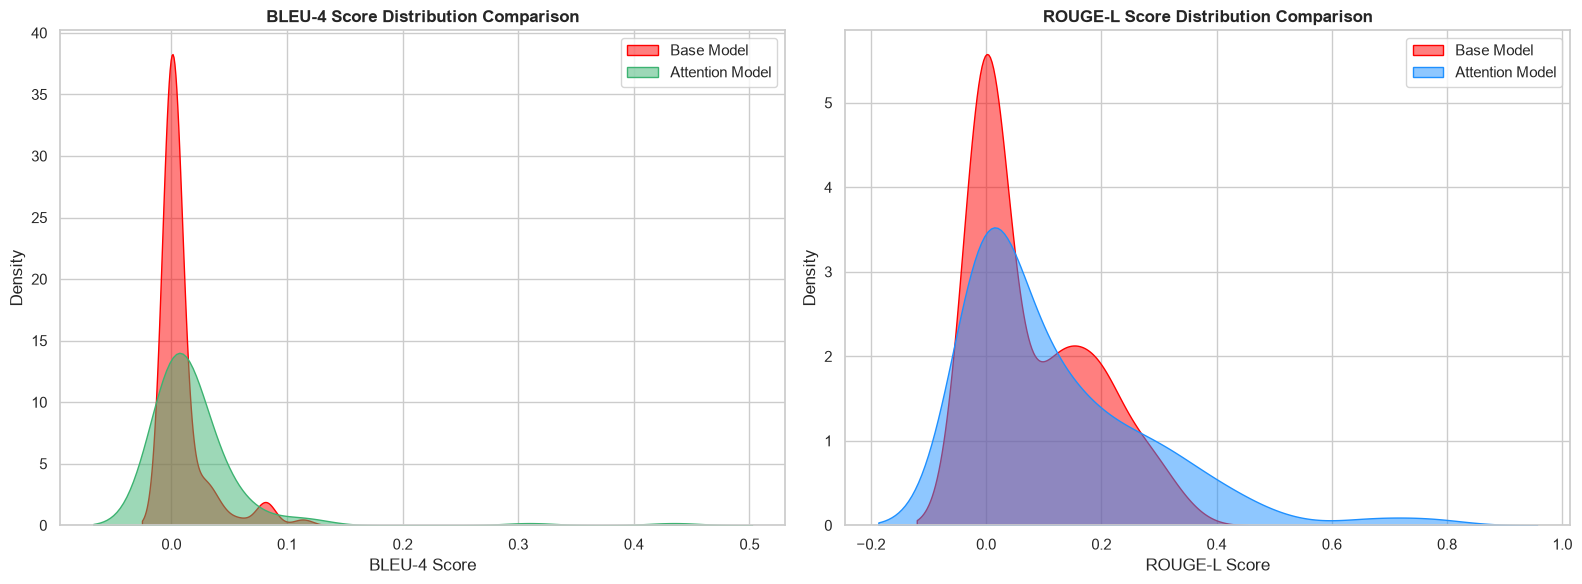


📝 Qualitative Head-to-Head Text Comparison:


,Input,Base_Prediction,Attn_Prediction,Target
0,this is what i'm trying to do. sudo imagemagi...,i is the,you have to do sudo apt-get update sudo apt-ge...,"also, you might want to find a better tutorial..."
1,Program for editing movies and uploading to yo...,i is the,how do i know how to do it,"Hmmn, I just need it to put a video on Youtube..."
2,which firewall?,i is the,i m trying to do it,you'll need to forward port 22 to your interna...
3,im afraid to install ubuntu and lose windows c...,i is the,i you to install ubuntu install ubuntu and i h...,yeah i was busy
4,there is xdesktop meta pakacge for sfce I guess,i is the,there is a <unk> for <unk> for <unk> i think i...,do you mean xubuntu-desktop?
5,seems a bit harsh - but if you are satisfied :),i is the,i m not sure if you are you,if i knew another way that works i'd use it
6,"no, f-spot was one example => anything else th...",i is the,no idea what you want to do that,normally i just restarted my system...i didnt ...
7,"Please don't flood, use http://paste.ubuntu.co...",i is the,you don t flood use enter as punctuation as pu...,"dpkg: parse error, in file `/var/lib/dpkg/stat..."
8,what other way could there be?,i is the,what do you want to be able to be able to be a...,it the next statement that i was having trubbl...
9,no. alsaconf doesn't do what asoundconf does.,i is the,no idea how do i do that,"works, thanks. does this constitute an excuse..."


In [24]:
# ==========================================
# CELL 10: HEAD-TO-HEAD MODEL COMPARISON
# ==========================================
import os
import json
import pickle
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# --- 1. RECREATING THE "BLACKBOX" BASELINE BLUEPRINTS ---
class BaseEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        
    def forward(self, src, src_len=None):
        embedded = self.embedding(src)
        outputs, hidden = self.gru(embedded)
        return outputs, hidden

class BaseDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, vocab_size) 
        
    def forward(self, dec_input, hidden):
        embedded = self.embedding(dec_input)
        output, hidden = self.gru(embedded, hidden)
        prediction = self.out(output.squeeze(1))
        return prediction, hidden

# --- 2. BASELINE BEAM SEARCH DECODER ---
def base_beam_search_decode(encoder, decoder, input_text, vocab, index2word, max_len, device, beam_width=5, alpha=1.2, min_length=4):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        tokens = clean_and_tokenize(input_text)
        if not tokens: tokens = ["<unk>"]
            
        seq = [vocab.get(t, vocab.get("<unk>", 1)) for t in tokens]
        padded_seq = seq + [vocab.get("<pad>", 0)] * max(0, (max_len - len(seq)))
        padded_seq = padded_seq[:max_len]
        
        src_tensor = torch.tensor([padded_seq], dtype=torch.long, device=device)
        
        _, hidden = encoder(src_tensor) 
        beams = [(0.0, [vocab.get("<sos>", 2)], hidden)]
        
        for _ in range(max_len):
            new_beams = []
            for score, current_seq, dec_hidden in beams:
                if current_seq[-1] == vocab.get("<eos>", 3):
                    new_beams.append((score, current_seq, dec_hidden))
                    continue
                    
                dec_input = torch.tensor([[current_seq[-1]]], dtype=torch.long, device=device)
                prediction, next_hidden = decoder(dec_input, dec_hidden)
                log_probs = F.log_softmax(prediction, dim=1).squeeze(0)
                
                if len(current_seq) < min_length and vocab.get("<eos>", 3) in vocab.values():
                    log_probs[vocab["<eos>"]] = float('-inf')
                if len(current_seq) > 1:
                    log_probs[current_seq[-1]] = float('-inf')
                
                topk_probs, topk_idx = log_probs.topk(beam_width)
                for i in range(beam_width):
                    new_seq = current_seq + [topk_idx[i].item()]
                    new_score = score + topk_probs[i].item()
                    new_beams.append((new_score, new_seq, next_hidden))
            
            new_beams = sorted(new_beams, key=lambda x: x[0] / (len(x[1])**alpha), reverse=True)
            beams = new_beams[:beam_width]
            if all(b[1][-1] == vocab.get("<eos>", 3) for b in beams): break
                
    best_seq = beams[0][1]
    ignore_tokens = [vocab.get("<pad>"), vocab.get("<sos>"), vocab.get("<eos>")]
    decoded_words = [index2word.get(idx, "<unk>") for idx in best_seq if idx not in ignore_tokens]
    return " ".join(decoded_words)

# --- 3. COMPARATIVE PIPELINE ---
def run_model_showdown(base_pack, attn_pack, df_test, device, sample_size=100):
    print(f"🥊 Initiating Head-to-Head Beam Search on {sample_size} samples...")
    
    metrics = []
    smooth = SmoothingFunction().method1
    rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    test_sample = df_test.sample(n=sample_size, random_state=42)
    
    for idx, row in test_sample.iterrows():
        src_text = row["input_text"]
        trg_text = row["target_text"]
        ref_tokens = clean_and_tokenize(trg_text)
        
        # Base Prediction
        base_pred = base_beam_search_decode(
            base_pack['enc'], base_pack['dec'], src_text, 
            base_pack['vocab'], base_pack['i2w'], base_pack['max_len'], device
        )
        if not base_pred.strip(): base_pred = "<empty>"
        base_bleu = sentence_bleu([ref_tokens], base_pred.split(), smoothing_function=smooth)
        base_rouge = rouge.score(" ".join(ref_tokens), base_pred)['rougeL'].fmeasure
        
        # Attention Prediction
        attn_pred = beam_search_decode(
            attn_pack['enc'], attn_pack['dec'], src_text, 
            attn_pack['vocab'], attn_pack['i2w'], device
        )
        if not attn_pred.strip(): attn_pred = "<empty>"
        attn_bleu = sentence_bleu([ref_tokens], attn_pred.split(), smoothing_function=smooth)
        attn_rouge = rouge.score(" ".join(ref_tokens), attn_pred)['rougeL'].fmeasure
        
        metrics.append({
            "Input": src_text, "Target": trg_text,
            "Base_Prediction": base_pred, "Attn_Prediction": attn_pred,
            "Base_BLEU": base_bleu, "Attn_BLEU": attn_bleu,
            "Base_ROUGE": base_rouge, "Attn_ROUGE": attn_rouge
        })

    df_results = pd.DataFrame(metrics)
    
    print("\n" + "="*70)
    print(" 🏆 HEAD-TO-HEAD GENERATIVE EVALUATION SUMMARY")
    print("="*70)
    summary_stats = pd.DataFrame({
        "Metric": ["Average BLEU-4", "Average ROUGE-L"],
        "Base Model (No Attention)": [df_results["Base_BLEU"].mean(), df_results["Base_ROUGE"].mean()],
        "Attention Model": [df_results["Attn_BLEU"].mean(), df_results["Attn_ROUGE"].mean()]
    })
    display(summary_stats.style.format({"Base Model (No Attention)": "{:.4f}", "Attention Model": "{:.4f}"}))
    print("="*70 + "\n")
    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.kdeplot(df_results["Base_BLEU"], fill=True, color="red", alpha=0.5, label="Base Model", ax=axes[0])
    sns.kdeplot(df_results["Attn_BLEU"], fill=True, color="mediumseagreen", alpha=0.5, label="Attention Model", ax=axes[0])
    axes[0].set_title("BLEU-4 Score Distribution Comparison", fontweight="bold")
    axes[0].set_xlabel("BLEU-4 Score")
    axes[0].legend()
    
    sns.kdeplot(df_results["Base_ROUGE"], fill=True, color="red", alpha=0.5, label="Base Model", ax=axes[1])
    sns.kdeplot(df_results["Attn_ROUGE"], fill=True, color="dodgerblue", alpha=0.5, label="Attention Model", ax=axes[1])
    axes[1].set_title("ROUGE-L Score Distribution Comparison", fontweight="bold")
    axes[1].set_xlabel("ROUGE-L Score")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    return df_results

# ==========================================
# --- 4. DATA LOADING & EXECUTION ---
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- LOAD BASELINE (Using the correct folder paths) ---
print("📦 Loading Baseline Assets...")
with open('baseline_model_deployment/baseline_model_config.json', 'r') as f: 
    base_cfg = json.load(f)
with open('baseline_model_deployment/baseline_vocab.pkl', 'rb') as f: 
    base_v = pickle.load(f)
    if 'vocab' in base_v: base_vocab, base_i2w = base_v['vocab'], base_v['index2word']
    else: base_vocab, base_i2w = base_v, {v: k for k, v in base_v.items()} 

b_enc = BaseEncoder(len(base_vocab), 256, 256).to(device)
b_dec = BaseDecoder(len(base_vocab), 256, 256).to(device)

# Note: Assuming your baseline .pth files are in the baseline folder. 
# If they are in the main directory, remove 'baseline_model_deployment/' from these two lines!
b_enc.load_state_dict(torch.load('baseline_model_deployment/baseline_encoder.pth', map_location=device, weights_only=True))
b_dec.load_state_dict(torch.load('baseline_model_deployment/baseline_decoder.pth', map_location=device, weights_only=True))

# --- LOAD ATTENTION (Using the correct folder paths) ---
print("📦 Loading Attention Assets...")
with open('chatbot_deployment/model_config.json', 'r') as f: 
    attn_cfg = json.load(f)
with open('chatbot_deployment/vocab.pkl', 'rb') as f: 
    attn_v = pickle.load(f)
    attn_vocab, attn_i2w = attn_v['vocab'], attn_v['index2word']

a_enc = PackedEncoder(len(attn_vocab), attn_cfg.get('EMBEDDING_DIM', 256), attn_cfg.get('HIDDEN_DIM', 512)).to(device)
a_dec = AttentionDecoder(len(attn_vocab), attn_cfg.get('EMBEDDING_DIM', 256), attn_cfg.get('HIDDEN_DIM', 512)).to(device)

a_enc.load_state_dict(torch.load('chatbot_deployment/attn_encoder_v2.pth', map_location=device, weights_only=True))
a_dec.load_state_dict(torch.load('chatbot_deployment/attn_decoder_v2.pth', map_location=device, weights_only=True))

base_pack = {'enc': b_enc, 'dec': b_dec, 'vocab': base_vocab, 'i2w': base_i2w, 'max_len': base_cfg.get('MAX_TARGET_LENGTH', 55)}
attn_pack = {'enc': a_enc, 'dec': a_dec, 'vocab': attn_vocab, 'i2w': attn_i2w}

results_df = run_model_showdown(base_pack, attn_pack, df_test, device, sample_size=100)

print("\n📝 Qualitative Head-to-Head Text Comparison:")
display(results_df[["Input", "Base_Prediction", "Attn_Prediction", "Target"]].head(10))

Loading Baseline Assets...
Loading Attention Assets...
Initiating Head-to-Head Advanced Beam Search on 100 samples...

ADVANCED HEAD-TO-HEAD EVALUATION SUMMARY


,Metric,Base Model,Attention Model
0,Average BLEU-4,0.0088,0.0224
1,Average ROUGE-L,0.0800,0.1187
2,Average METEOR,0.0362,0.0844
3,Distinct-1 (Vocab Diversity),0.0100,0.0829
4,Distinct-2 (Phrase Diversity),0.0100,0.2618


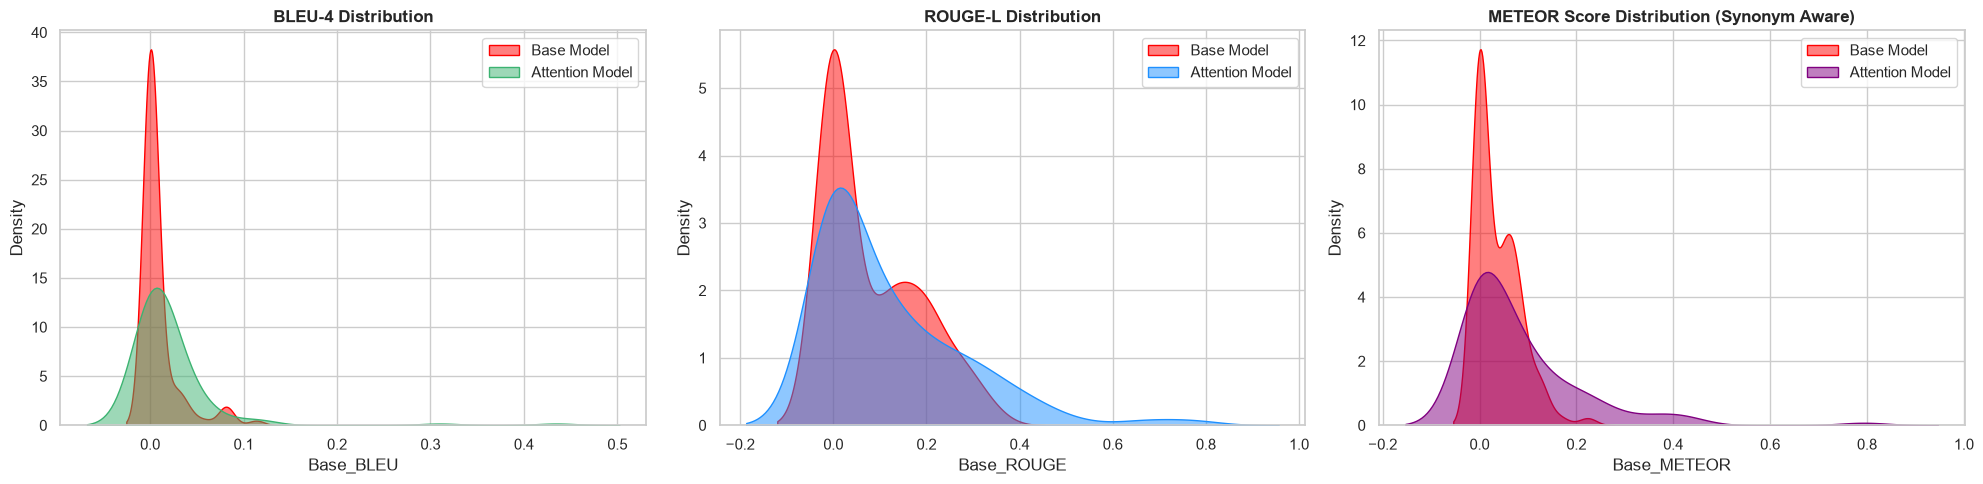


 Qualitative Head-to-Head Text Comparison:


,Input,Base_Prediction,Attn_Prediction,Target
0,this is what i'm trying to do. sudo imagemagi...,i is the,you have to do sudo apt-get update sudo apt-ge...,"also, you might want to find a better tutorial..."
1,Program for editing movies and uploading to yo...,i is the,how do i know how to do it,"Hmmn, I just need it to put a video on Youtube..."
2,which firewall?,i is the,i m trying to do it,you'll need to forward port 22 to your interna...
3,im afraid to install ubuntu and lose windows c...,i is the,i you to install ubuntu install ubuntu and i h...,yeah i was busy
4,there is xdesktop meta pakacge for sfce I guess,i is the,there is a <unk> for <unk> for <unk> i think i...,do you mean xubuntu-desktop?
5,seems a bit harsh - but if you are satisfied :),i is the,i m not sure if you are you,if i knew another way that works i'd use it
6,"no, f-spot was one example => anything else th...",i is the,no idea what you want to do that,normally i just restarted my system...i didnt ...
7,"Please don't flood, use http://paste.ubuntu.co...",i is the,you don t flood use enter as punctuation as pu...,"dpkg: parse error, in file `/var/lib/dpkg/stat..."
8,what other way could there be?,i is the,what do you want to be able to be able to be a...,it the next statement that i was having trubbl...
9,no. alsaconf doesn't do what asoundconf does.,i is the,no idea how do i do that,"works, thanks. does this constitute an excuse..."


In [ ]:
# ==========================================
# CELL 10: ADVANCED HEAD-TO-HEAD COMPARISON
# ==========================================
import os
import json
import pickle
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

# Ensure WordNet is downloaded for METEOR synonym matching
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# --- 1. RECREATING THE "BLACKBOX" BASELINE BLUEPRINTS ---
class BaseEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        
    def forward(self, src, src_len=None):
        embedded = self.embedding(src)
        outputs, hidden = self.gru(embedded)
        return outputs, hidden

class BaseDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, vocab_size) 
        
    def forward(self, dec_input, hidden):
        embedded = self.embedding(dec_input)
        output, hidden = self.gru(embedded, hidden)
        prediction = self.out(output.squeeze(1))
        return prediction, hidden

# --- 2. BASELINE BEAM SEARCH DECODER ---
def base_beam_search_decode(encoder, decoder, input_text, vocab, index2word, max_len, device, beam_width=5, alpha=1.2, min_length=4):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        tokens = clean_and_tokenize(input_text)
        if not tokens: tokens = ["<unk>"]
            
        seq = [vocab.get(t, vocab.get("<unk>", 1)) for t in tokens]
        padded_seq = seq + [vocab.get("<pad>", 0)] * max(0, (max_len - len(seq)))
        padded_seq = padded_seq[:max_len]
        
        src_tensor = torch.tensor([padded_seq], dtype=torch.long, device=device)
        
        _, hidden = encoder(src_tensor) 
        beams = [(0.0, [vocab.get("<sos>", 2)], hidden)]
        
        for _ in range(max_len):
            new_beams = []
            for score, current_seq, dec_hidden in beams:
                if current_seq[-1] == vocab.get("<eos>", 3):
                    new_beams.append((score, current_seq, dec_hidden))
                    continue
                    
                dec_input = torch.tensor([[current_seq[-1]]], dtype=torch.long, device=device)
                prediction, next_hidden = decoder(dec_input, dec_hidden)
                log_probs = F.log_softmax(prediction, dim=1).squeeze(0)
                
                if len(current_seq) < min_length and vocab.get("<eos>", 3) in vocab.values():
                    log_probs[vocab["<eos>"]] = float('-inf')
                if len(current_seq) > 1:
                    log_probs[current_seq[-1]] = float('-inf')
                
                topk_probs, topk_idx = log_probs.topk(beam_width)
                for i in range(beam_width):
                    new_seq = current_seq + [topk_idx[i].item()]
                    new_score = score + topk_probs[i].item()
                    new_beams.append((new_score, new_seq, next_hidden))
            
            new_beams = sorted(new_beams, key=lambda x: x[0] / (len(x[1])**alpha), reverse=True)
            beams = new_beams[:beam_width]
            if all(b[1][-1] == vocab.get("<eos>", 3) for b in beams): break
                
    best_seq = beams[0][1]
    ignore_tokens = [vocab.get("<pad>"), vocab.get("<sos>"), vocab.get("<eos>")]
    decoded_words = [index2word.get(idx, "<unk>") for idx in best_seq if idx not in ignore_tokens]
    return " ".join(decoded_words)

# --- 3. DIVERSITY METRIC CALCULATOR (DISTINCT-N) ---
def calculate_distinct_n(predictions, n):
    """Calculates the percentage of unique n-grams across the entire generated corpus."""
    ngrams = []
    for text in predictions:
        tokens = text.split()
        ngrams.extend(zip(*[tokens[i:] for i in range(n)]))
    if len(ngrams) == 0: return 0.0
    return len(set(ngrams)) / len(ngrams)

# --- 4. ADVANCED COMPARATIVE PIPELINE ---
def run_model_showdown(base_pack, attn_pack, df_test, device, sample_size=100):
    print(f"Initiating Head-to-Head Advanced Beam Search on {sample_size} samples...")
    
    metrics = []
    smooth = SmoothingFunction().method1
    rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    test_sample = df_test.sample(n=sample_size, random_state=42)
    
    all_base_preds = []
    all_attn_preds = []
    
    for idx, row in test_sample.iterrows():
        src_text = row["input_text"]
        trg_text = row["target_text"]
        ref_tokens = clean_and_tokenize(trg_text)
        
        # Base Prediction
        base_pred = base_beam_search_decode(
            base_pack['enc'], base_pack['dec'], src_text, 
            base_pack['vocab'], base_pack['i2w'], base_pack['max_len'], device
        )
        if not base_pred.strip(): base_pred = "<empty>"
        base_tokens = base_pred.split()
        all_base_preds.append(base_pred)
        
        base_bleu = sentence_bleu([ref_tokens], base_tokens, smoothing_function=smooth)
        base_rouge = rouge.score(" ".join(ref_tokens), base_pred)['rougeL'].fmeasure
        base_meteor = meteor_score([ref_tokens], base_tokens)
        
        # Attention Prediction
        attn_pred = beam_search_decode(
            attn_pack['enc'], attn_pack['dec'], src_text, 
            attn_pack['vocab'], attn_pack['i2w'], device
        )
        if not attn_pred.strip(): attn_pred = "<empty>"
        attn_tokens = attn_pred.split()
        all_attn_preds.append(attn_pred)
        
        attn_bleu = sentence_bleu([ref_tokens], attn_tokens, smoothing_function=smooth)
        attn_rouge = rouge.score(" ".join(ref_tokens), attn_pred)['rougeL'].fmeasure
        attn_meteor = meteor_score([ref_tokens], attn_tokens)
        
        metrics.append({
            "Input": src_text, "Target": trg_text,
            "Base_Prediction": base_pred, "Attn_Prediction": attn_pred,
            "Base_BLEU": base_bleu, "Attn_BLEU": attn_bleu,
            "Base_ROUGE": base_rouge, "Attn_ROUGE": attn_rouge,
            "Base_METEOR": base_meteor, "Attn_METEOR": attn_meteor
        })

    df_results = pd.DataFrame(metrics)
    
    # Calculate Corpus-Level Diversity
    base_dist1 = calculate_distinct_n(all_base_preds, 1)
    base_dist2 = calculate_distinct_n(all_base_preds, 2)
    attn_dist1 = calculate_distinct_n(all_attn_preds, 1)
    attn_dist2 = calculate_distinct_n(all_attn_preds, 2)
    
    print("\n" + "="*80)
    print("ADVANCED HEAD-TO-HEAD EVALUATION SUMMARY")
    print("="*80)
    summary_stats = pd.DataFrame({
        "Metric": ["Average BLEU-4", "Average ROUGE-L", "Average METEOR", "Distinct-1 (Vocab Diversity)", "Distinct-2 (Phrase Diversity)"],
        "Base Model": [df_results["Base_BLEU"].mean(), df_results["Base_ROUGE"].mean(), df_results["Base_METEOR"].mean(), base_dist1, base_dist2],
        "Attention Model": [df_results["Attn_BLEU"].mean(), df_results["Attn_ROUGE"].mean(), df_results["Attn_METEOR"].mean(), attn_dist1, attn_dist2]
    })
    display(summary_stats.style.format({"Base Model": "{:.4f}", "Attention Model": "{:.4f}"}))
    print("="*80 + "\n")
    
    # 3-Panel Visualization
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # BLEU
    sns.kdeplot(df_results["Base_BLEU"], fill=True, color="red", alpha=0.5, label="Base Model", ax=axes[0])
    sns.kdeplot(df_results["Attn_BLEU"], fill=True, color="mediumseagreen", alpha=0.5, label="Attention Model", ax=axes[0])
    axes[0].set_title("BLEU-4 Distribution", fontweight="bold")
    axes[0].legend()
    
    # ROUGE
    sns.kdeplot(df_results["Base_ROUGE"], fill=True, color="red", alpha=0.5, label="Base Model", ax=axes[1])
    sns.kdeplot(df_results["Attn_ROUGE"], fill=True, color="dodgerblue", alpha=0.5, label="Attention Model", ax=axes[1])
    axes[1].set_title("ROUGE-L Distribution", fontweight="bold")
    axes[1].legend()

    # METEOR
    sns.kdeplot(df_results["Base_METEOR"], fill=True, color="red", alpha=0.5, label="Base Model", ax=axes[2])
    sns.kdeplot(df_results["Attn_METEOR"], fill=True, color="purple", alpha=0.5, label="Attention Model", ax=axes[2])
    axes[2].set_title("METEOR Score Distribution (Synonym Aware)", fontweight="bold")
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    return df_results

# ==========================================
# --- 5. DATA LOADING & EXECUTION ---
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading Baseline Assets...")
with open('baseline_model_deployment/baseline_model_config.json', 'r') as f: 
    base_cfg = json.load(f)
with open('baseline_model_deployment/baseline_vocab.pkl', 'rb') as f: 
    base_v = pickle.load(f)
    if 'vocab' in base_v: base_vocab, base_i2w = base_v['vocab'], base_v['index2word']
    else: base_vocab, base_i2w = base_v, {v: k for k, v in base_v.items()} 

b_enc = BaseEncoder(len(base_vocab), 256, 256).to(device)
b_dec = BaseDecoder(len(base_vocab), 256, 256).to(device)

b_enc.load_state_dict(torch.load('baseline_model_deployment/baseline_encoder.pth', map_location=device, weights_only=True))
b_dec.load_state_dict(torch.load('baseline_model_deployment/baseline_decoder.pth', map_location=device, weights_only=True))

print("Loading Attention Assets...")
with open('attention_model_deployment/model_config.json', 'r') as f: 
    attn_cfg = json.load(f)
with open('attention_model_deployment/vocab.pkl', 'rb') as f: 
    attn_v = pickle.load(f)
    attn_vocab, attn_i2w = attn_v['vocab'], attn_v['index2word']

a_enc = PackedEncoder(len(attn_vocab), attn_cfg.get('EMBEDDING_DIM', 256), attn_cfg.get('HIDDEN_DIM', 512)).to(device)
a_dec = AttentionDecoder(len(attn_vocab), attn_cfg.get('EMBEDDING_DIM', 256), attn_cfg.get('HIDDEN_DIM', 512)).to(device)

a_enc.load_state_dict(torch.load('attention_model_deployment/attn_encoder_v2.pth', map_location=device, weights_only=True))
a_dec.load_state_dict(torch.load('attention_model_deployment/attn_decoder_v2.pth', map_location=device, weights_only=True))

base_pack = {'enc': b_enc, 'dec': b_dec, 'vocab': base_vocab, 'i2w': base_i2w, 'max_len': base_cfg.get('MAX_TARGET_LENGTH', 55)}
attn_pack = {'enc': a_enc, 'dec': a_dec, 'vocab': attn_vocab, 'i2w': attn_i2w}

results_df = run_model_showdown(base_pack, attn_pack, df_test, device, sample_size=100)

# --- 6. QUALITATIVE TEXT COMPARISON ---
print("\n Qualitative Head-to-Head Text Comparison:")
display(results_df[["Input", "Base_Prediction", "Attn_Prediction", "Target"]].head(10))